# Experiment Analysis

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
name = ['SK1-052 9.6 kPa-650C', 'TCM2-027 9.6 kPa-650C', 'TCM2-071 9.6 kPa-650C']
number = ['45', '22', '16']

exp = {}

for sname, anum in zip(name, number):
    df = pd.read_excel('230319 TCM Al content 9.6 kPa.xlsx', sheet_name=sname)
    df.columns = df.columns.str.strip()

    time_col, total_al_col, al_col, error_col, rate_col = 'Time / h', 'Total Al / uc', 'Al/uc', 'Error Al/uc', 'Rate / mol ucˆ-1 hˆ-1'
    si_al_col = 'Si/Al'

    df_clean = df[[time_col, total_al_col, al_col, error_col, rate_col]].dropna()

    time_data      = pd.to_numeric(df_clean[time_col], errors='coerce').to_numpy()
    total_al_data  = pd.to_numeric(df_clean[total_al_col], errors='coerce').to_numpy()
    al_f_data   = pd.to_numeric(df_clean[al_col], errors='coerce').to_numpy()
    errors_data    = pd.to_numeric(df_clean[error_col], errors='coerce').to_numpy()
    rate_data      = pd.to_numeric(df_clean[rate_col], errors='coerce').to_numpy()

    exp[anum] = {
        'time':  time_data,
        'Al_f':  al_f_data,
        'Al_tot': total_al_data[0],
        'error': errors_data,
        'rate':  rate_data,
    }

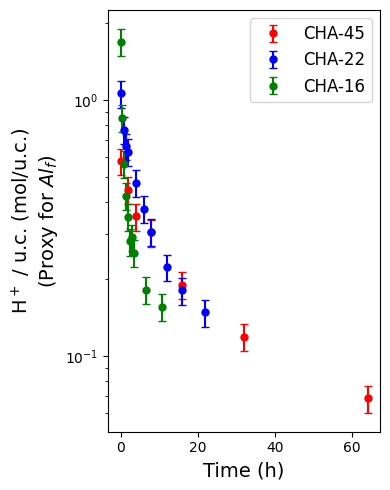

In [3]:
name_list = ['CHA-45', 'CHA-22', 'CHA-16']
colors = {'45': 'r', '22': 'b', '16': 'g'}

fig, ax = plt.subplots(figsize=(4, 5))

for idx, key in enumerate(['45','22','16']):
    ax.errorbar(
        exp[key]['time'],
        exp[key]['Al_f'],
        yerr=exp[key]['error'],
        fmt='o',
        markersize=5,
        capsize=3,
        linewidth=1.5,
        label=name_list[idx],
        color = colors[key]
    )

ax.set_xlabel('Time (h)', fontsize=14)
ax.set_ylabel('H$^+$ / u.c. (mol/u.c.)\n(Proxy for $Al_f$)', fontsize=14)
ax.set_yscale("log")
ax.legend(fontsize=12)
fig.tight_layout()
plt.show()

In [5]:
def integrated_rate_law(t, k_app, n, Al_f0):
    """
    Integrated rate law for -d[Al_f]/dt = k_app * [Al_f]^n
    
    For n ≠ 1: [Al_f]^(1-n) = [Al_f0]^(1-n) - k_app*(1-n)*t
    For n = 1: ln([Al_f]) = ln([Al_f0]) - k_app*t
    
    We use a smooth approximation near n=1 to avoid singularity
    """
    epsilon = 1e-6  # threshold for considering n ≈ 1
    
    if abs(n - 1) < epsilon:
        # First-order kinetics: [Al_f] = [Al_f0] * exp(-k_app*t)
        return Al_f0 * np.exp(-k_app * t)
    else:
        # General order kinetics
        term = Al_f0**(1-n) - k_app * (1-n) * t
        # Ensure we don't get negative values under the power
        term = np.maximum(term, 1e-10)
        return term**(1/(1-n))

In [6]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
# Fit each dataset
results = {}

for key, dataset in exp.items():
    time = dataset['time']
    Al_f = dataset['Al_f']
    Al_f0 = Al_f[0]  # Initial concentration
    
    # Initial guesses: k_app ~ 0.01, n ~ 1 (first order)
    # We'll try multiple initial guesses to avoid local minima
    initial_guesses = [
        (0.01, 1.0, Al_f0),
        (0.1, 0.5, Al_f0),
        (0.05, 1.5, Al_f0),
        (0.001, 2.0, Al_f0)
    ]
    
    best_fit = None
    best_error = np.inf
    
    for guess in initial_guesses:
        try:
            # Fit the data
            popt, pcov = curve_fit(
                integrated_rate_law, 
                time, 
                Al_f, 
                p0=guess,
                bounds=([0, 0, Al_f0*0.9], [np.inf, 5, Al_f0*1.1]),
                maxfev=10000
            )
            
            # Calculate residual error
            predicted = integrated_rate_law(time, *popt)
            error = np.sum((Al_f - predicted)**2)
            
            if error < best_error:
                best_error = error
                best_fit = (popt, pcov)
        except:
            continue
    
    if best_fit is not None:
        popt, pcov = best_fit
        k_app, n, Al_f0_fit = popt
        
        # Calculate standard errors
        perr = np.sqrt(np.diag(pcov))
        
        # Calculate R²
        predicted = integrated_rate_law(time, *popt)
        ss_res = np.sum((Al_f - predicted)**2)
        ss_tot = np.sum((Al_f - np.mean(Al_f))**2)
        r_squared = 1 - (ss_res / ss_tot)
        
        results[key] = {
            'k_app': k_app,
            'n': n,
            'Al_f0': Al_f0_fit,
            'k_app_err': perr[0],
            'n_err': perr[1],
            'R2': r_squared
        }
        
        print(f"\n{'='*60}")
        print(f"Dataset: {key}")
        print(f"{'='*60}")
        print(f"Apparent rate constant (k_app): {k_app:.6f} ± {perr[0]:.6f}")
        print(f"Reaction order (n):              {n:.4f} ± {perr[1]:.4f}")
        print(f"Initial [Al_f]:                  {Al_f0_fit:.6f} ± {perr[2]:.6f}")
        print(f"R²:                              {r_squared:.6f}")


Dataset: 45
Apparent rate constant (k_app): 0.284419 ± 0.066554
Reaction order (n):              2.2224 ± 0.2021
Initial [Al_f]:                  0.574042 ± 0.015609
R²:                              0.994688

Dataset: 22
Apparent rate constant (k_app): 0.357948 ± 0.021087
Reaction order (n):              2.2778 ± 0.0928
Initial [Al_f]:                  1.056733 ± 0.015970
R²:                              0.997607

Dataset: 16
Apparent rate constant (k_app): 1.210800 ± 0.063497
Reaction order (n):              2.2956 ± 0.1115
Initial [Al_f]:                  1.694248 ± 0.028817
R²:                              0.997007


In [7]:
def log_integrated_rate_law(t, k_app, n, Al_f0):
    """Wrapper that returns log([Al_f]) for log-space fitting."""
    Al_f = integrated_rate_law(t, k_app, n, Al_f0)
    return np.log(np.maximum(Al_f, 1e-10))

results = {}
for key, dataset in exp.items():
    time = dataset['time']
    Al_f = dataset['Al_f']
    Al_f0 = Al_f[0]
    log_Al_f = np.log(Al_f)  # <-- fit target is now log([Al_f])

    initial_guesses = [
        (0.01, 1.0, Al_f0),
        (0.1,  0.5, Al_f0),
        (0.05, 1.5, Al_f0),
        (0.001,2.0, Al_f0),
    ]

    best_fit, best_error = None, np.inf

    for guess in initial_guesses:
        try:
            popt, pcov = curve_fit(
                log_integrated_rate_law,   # <-- log-space model
                time,
                log_Al_f,                  # <-- log-space data
                p0=guess,
                bounds=([0, 0, Al_f0*0.9], [np.inf, 5, Al_f0*1.1]),
                maxfev=10000
            )
            predicted_log = log_integrated_rate_law(time, *popt)
            error = np.sum((log_Al_f - predicted_log)**2)
            if error < best_error:
                best_error = error
                best_fit = (popt, pcov)
        except:
            continue

    if best_fit is not None:
        popt, pcov = best_fit
        k_app, n, Al_f0_fit = popt
        perr = np.sqrt(np.diag(pcov))

        # R² in log-space (what you're actually optimizing)
        predicted_log = log_integrated_rate_law(time, *popt)
        ss_res = np.sum((log_Al_f - predicted_log)**2)
        ss_tot = np.sum((log_Al_f - np.mean(log_Al_f))**2)
        r_squared_log = 1 - ss_res / ss_tot

        results[key] = {
            'k_app': k_app, 'n': n, 'Al_f0': Al_f0_fit,
            'k_app_err': perr[0], 'n_err': perr[1],
            'R2': r_squared_log
        }

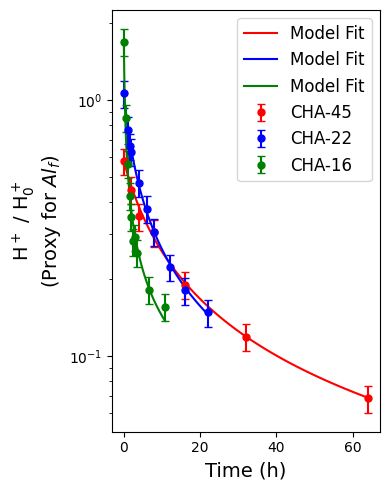

In [9]:
fig, ax = plt.subplots(figsize=(4, 5))
for key in ['45','22','16']:
    # key = '45'
    k=results[key]['k_app']
    n=results[key]['n']
    Alf0 = exp[key]['Al_f'][0]
    t=np.linspace(0,exp[key]['time'][-1],100)
    f = lambda t: (Alf0**(1-n)+(n-1)*k*t)**(1/(1-n))
    plt.errorbar(
            exp[key]['time'],
            exp[key]['Al_f'],
            yerr=exp[key]['error'],
            fmt='o',
            markersize=5,
            capsize=3,
            linewidth=1.5,
            label=f'CHA-{key}',
            color = colors[key]
        )
    plt.plot(t, f(t), color = colors[key],label='Model Fit')
plt.xlabel('Time (h)', fontsize=14)
plt.ylabel('H$^+$ / H$^+_0$\n(Proxy for $Al_f$)', fontsize=14)
plt.yscale("log")
plt.legend(fontsize=12)
fig.tight_layout()
plt.show()

# Bayesian Optimization

In [2]:
from scipy.stats.qmc import LatinHypercube
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
from scipy.optimize import minimize
from scipy.stats import norm
import warnings
from zmc import Zmc

In [7]:
vol     = 1743432.3688417426   # Å³, 9x9x9 CHA supercell volume
rho_Cu  = 0.083

P_O2_exp = x                  # kPa
r_exp    = y * 1e-3            # mol NO / (mol Cu * s)

# Parameter bounds: 0 < k_red < 0.2, 0 < k_ox < 0.2, 0 < D < 60
bounds = np.array([[1e-3, 0.2 ],   # k_red
                   [1e-3, 0.2 ],   # k_ox
                   [1.0,  60.0]])  # D (Å)

def evaluate(k_red, k_ox, D):
    """Run kMC at all experimental P_O2 values and return RMSE against r_exp."""
    Ap = k_ox * vol / 1000
    rates = []
    for P_O2 in P_O2_exp:
        try:
            calc = Zmc(Ar=k_red, Ap=Ap, P_O2=float(P_O2), D=D, rho_Cu=rho_Cu, short=True)
            calc.calculate()
            calc.get_fraction()
            ss_fraction, _, _, _ = calc.get_fraction()
            ss_rate = calc.get_rate()
            rates.append(ss_rate)
        except Exception:
            rates.append(np.nan)
    rates = np.array(rates)
    if np.any(np.isnan(rates)):
        return np.inf
    return np.sqrt(np.mean((rates - r_exp) ** 2))
    

In [8]:
# Latin Hypercube Sampling: 200 initial training points
sampler  = LatinHypercube(d=3, seed=42)
lhs_unit = sampler.random(n=100)
X_lhs    = lhs_unit * (bounds[:, 1] - bounds[:, 0]) + bounds[:, 0]

print(f'Running 200 LHS evaluations...')
Y_lhs = []
for i, (k_red, k_ox, D) in enumerate(X_lhs):
    obj = evaluate(k_red, k_ox, D)
    Y_lhs.append(obj)
    print(f'[{i+1:3d}/200] k_red={k_red:.4f}, k_ox={k_ox:.4f}, D={D:.2f} -> RMSE={obj:.6f}')

Y_lhs = np.array(Y_lhs)
np.save('X_lhs.npy', X_lhs)
np.save('Y_lhs.npy', Y_lhs)
print('LHS done.')

Running 200 LHS evaluations...
EWMA not converged, using mean of recorded CuII fraction: 0.23994252873563215
EWMA not converged, using mean of recorded CuII fraction: 0.23994252873563215
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
EWMA not converged, using mean of recorded CuII fraction: 0.5050156739811913
EWMA not converged, using mean of recorded CuII fraction: 0.5050156739811913
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculat

/Users/slee75/Desktop/dealumination/dealumination/kMC/zmc/outputters.py:90: RankWarning: Polyfit may be poorly conditioned
  model = np.polyfit(self.t[self.cutoff :],self.rev[self.cutoff :],1)


Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
EWMA not converged, using mean of recorded CuII fraction: 0.58128078817734
EWMA not converged, using mean of recorded CuII fraction: 0.58128078817734
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
[  5/200] k_red=0.0773, k_ox=0.0232, D=34.96 -> RMSE=0.028939
Simulation sufficiently converged. Calculating averages
Simu

/Users/slee75/Desktop/dealumination/dealumination/kMC/zmc/outputters.py:90: RankWarning: Polyfit may be poorly conditioned
  model = np.polyfit(self.t[self.cutoff :],self.rev[self.cutoff :],1)


Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating a

KeyboardInterrupt: 

In [ ]:
# Fit GP with Matern 5/2 kernel on valid LHS points
kernel = ConstantKernel(1.0) * Matern(nu=2.5)
gp     = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10,
                                   normalize_y=True, alpha=1e-6)

valid  = np.isfinite(Y_lhs)
X_bo   = X_lhs[valid].tolist()
Y_bo   = Y_lhs[valid].tolist()
gp.fit(np.array(X_bo), np.array(Y_bo))

def neg_EI(x_new, gp, y_best):
    x_new = np.array(x_new).reshape(1, -1)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        mu, sigma = gp.predict(x_new, return_std=True)
    z  = (y_best - mu[0]) / (sigma[0] + 1e-9)
    ei = (y_best - mu[0]) * norm.cdf(z) + sigma[0] * norm.pdf(z)
    return -ei

scipy_bounds = [(b[0], b[1]) for b in bounds]
n_bo_iter    = 50

for i in range(n_bo_iter):
    y_best = min(Y_bo)

    best_x, best_val = None, np.inf
    for _ in range(50):
        x0  = np.array([np.random.uniform(b[0], b[1]) for b in bounds])
        res = minimize(neg_EI, x0, args=(gp, y_best),
                       bounds=scipy_bounds, method='L-BFGS-B')
        if res.fun < best_val:
            best_val = res.fun
            best_x   = res.x

    k_red, k_ox, D = best_x
    obj = evaluate(k_red, k_ox, D)
    print(f'BO [{i+1:2d}/{n_bo_iter}] k_red={k_red:.4f}, k_ox={k_ox:.4f}, D={D:.2f} -> RMSE={obj:.6f}')

    X_bo.append(best_x)
    Y_bo.append(obj)

    valid_bo = [np.isfinite(yv) for yv in Y_bo]
    gp.fit(np.array(X_bo)[valid_bo], np.array(Y_bo)[valid_bo])

np.save('X_bo.npy', np.array(X_bo))
np.save('Y_bo.npy', np.array(Y_bo))

In [ ]:
# Best parameters and plot
best_idx              = np.argmin(Y_bo)
k_red_opt, k_ox_opt, D_opt = X_bo[best_idx]
print(f'Best parameters:')
print(f'  k_red = {k_red_opt:.4f}')
print(f'  k_ox  = {k_ox_opt:.4f}')
print(f'  D     = {D_opt:.2f} A')
print(f'  RMSE  = {Y_bo[best_idx]:.6f} mol NO / (mol Cu * s)')

Ap_opt = k_ox_opt * vol / 1000
r_opt  = []
for P_O2 in P_O2_exp:
    try:
        calc = Zmc(Ar=k_red_opt, Ap=Ap_opt, P_O2=float(P_O2), D=D_opt, rho_Cu=rho_Cu, short=True)
        calc.calculate()
        calc.get_fraction()
        r_opt.append(calc.get_rate())
    except Exception:
        r_opt.append(np.nan)

In [ ]:
plt.figure(figsize=(4, 4))
plt.plot(P_O2_exp, r_exp * 1e3, 'o', label='Experiment')
plt.plot(P_O2_exp, np.array(r_opt) * 1e3, 'o', label='kMC (optimized)')
plt.xlabel(r'$O_2$ pressure (kPa)', fontsize=12)
plt.ylabel(r'SCR Rate/$10^{-3}$ (mol NO / (mol Cu * s))', fontsize=12)
plt.tick_params(direction='in')
plt.legend()
plt.tight_layout()
plt.show()